# How to decrease GPU memory peak
#### Author: Michał Krutul
As deep learning models grow more complex, handling memory efficiently becomes critical to achieving successful, scalable training. This colab is designed to provide you with hands-on experience in implementing and optimizing strategies to overcome OOM issues, ensuring that your models can be trained effectively even with limited memory resources.

Today we'll explore three techniques for memory optimization:
* activation checkpointing
* gradient accumulation
* last layer chunking

# Monitoring
During our lab we will need to monitor GPU RAM usage to easily compare two approaches. If you use google colab (highly encouraged) open monitoring view by clicking 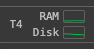 in top-right corner.

You should see something similar to this: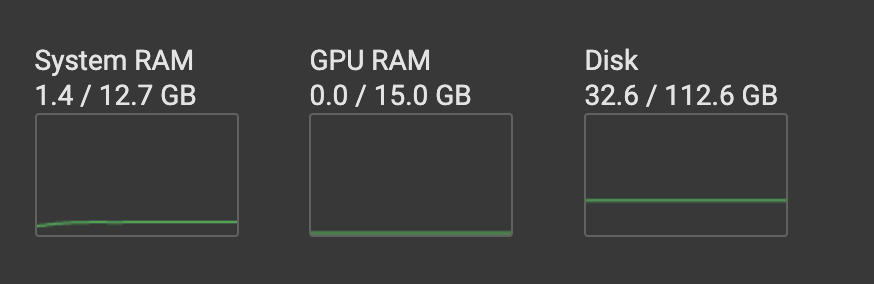

# Empty GPU cache
If emptying gpu cache would not work, you can try deleting session and starting over with empty memory.

# Setup

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.utils.checkpoint as checkpoint
import copy
from types import SimpleNamespace
import numpy as np
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
import torch.nn.functional as F

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if device.type == 'cpu':
  print(f"Device type is: {device}. You should change it to GPU.")
else:
  print(f"Device type is: {device}")

Device type is: cuda


In [3]:
class DummyDataset(Dataset):
    """
    A dummy dataset that always returns the same elements if unshuffled.

    This dataset generates deterministic random sequences of token IDs
    and attention masks based on a fixed base seed and the index of the sample.
    Each item fetched from this dataset will be reproducible dict which contain:
    - input_ids: A tensor of randomly generated token IDs.
    - attention_mask: A tensor of ones indicating full attention.
    - labels: A tensor of randomly generated labels
    """

    def __init__(self, num_samples, seq_length, vocab_size=50265):
        self.num_samples = num_samples
        self.seq_length = seq_length
        self.vocab_size = vocab_size
        self.base_seed = 42  # Base seed for reproducibility

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # Create a unique seed for each index
        seed = self.base_seed + idx
        generator = torch.Generator()
        generator.manual_seed(seed)

        # Generate deterministic random tokens (input_ids) with the correct shape
        input_ids = torch.randint(
            low=0,
            high=self.vocab_size,
            size=(self.seq_length,),
            dtype=torch.long,
            generator=generator
        )

        # Create an attention mask with full attention (all ones)
        attention_mask = torch.ones(self.seq_length, dtype=torch.long)

        labels = torch.randint(
            low=0,
            high=self.vocab_size,
            size=(self.seq_length,),
            dtype=torch.long,
            generator=generator
        )

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'labels': labels.squeeze(0)
        }

## Basic Trasformer implementation

In [4]:
class EmbeddingLayer(nn.Module):
    """
    Layer containing both token_embedding and positio§n_embedding.
    """
    def __init__(self, vocab_size, embed_dim, max_len):
        super(EmbeddingLayer, self).__init__()
        self.token_embedding = nn.Embedding(vocab_size, embed_dim)
        self.position_embedding = nn.Embedding(max_len, embed_dim)

    def forward(self, x):
        # x: (batch_size, seq_len)
        seq_len = x.size(1)
        positions = torch.arange(seq_len, dtype=torch.long, device=x.device).unsqueeze(0).expand_as(x)
        token_embeddings = self.token_embedding(x)
        position_embeddings = self.position_embedding(positions)
        embeddings = token_embeddings + position_embeddings
        return embeddings


In [5]:
class Transformer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.embedding_layer = EmbeddingLayer(config.vocab_size, config.d_model, config.max_len)
        self.blocks = nn.ModuleList([
            nn.TransformerDecoderLayer(
                d_model=config.d_model,
                nhead=config.num_heads,
                dim_feedforward=config.dim_feedforward,
                dropout=config.dropout,
                activation='relu',
                batch_first=True
            ) for _ in range(config.num_layers)
        ])

        self.head = nn.Linear(config.d_model, config.vocab_size)

    def forward(self, input_ids, attention_mask=None):
        batch_size, seq_len = input_ids.size()
        output = self.embedding_layer(input_ids)

        for block in self.blocks:
            output = block(output, output, tgt_mask=attention_mask)

        output = self.head(output)
        return output



In [6]:
from math import e
def train_model(config, reference_model, snapshot_filename):
  """
  Reference model is to copy model
  """
  dataset = DummyDataset(num_samples=config.num_samples, seq_length=config.seq_length, vocab_size=config.vocab_size)
  dataloader = DataLoader(dataset, batch_size=config.batch_size, shuffle=False)
  model = Transformer(config)
  model.load_state_dict(reference_model.state_dict())
  model.to(device)
  loss_fn = CrossEntropyLoss()
  optimizer = AdamW(model.parameters(), lr=1e-4)

  if snapshot_filename is not None:
    torch.cuda.memory._record_memory_history()
  else:
    torch.cuda.memory._record_memory_history(enabled=None)


  losses = []
  model.train()
  for batch in dataloader:
    input_ids = batch['input_ids'].to(device)
    labels = batch['labels'].to(device)

    optimizer.zero_grad()
    outputs = model(input_ids)

    loss = loss_fn(outputs.view(-1, config.vocab_size), labels.view(-1))
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
  if snapshot_filename is not None:
    torch.cuda.memory._dump_snapshot(f"{snapshot_filename}.pickle")
  return losses

In [7]:
mini_config = SimpleNamespace(
    vocab_size=128,
    max_len=24,
    d_model=16,
    num_heads=2,
    dim_feedforward=2048,
    num_layers=2,
    dropout=0.0,
    num_samples=64,
    seq_length=18,
    batch_size=8,
    chunks=4
)

In [8]:
mini_reference_model = Transformer(mini_config)
reference_losses = train_model(mini_config, mini_reference_model, "mini")

In [9]:
config = SimpleNamespace(
    vocab_size=32000,
    max_len=1024,
    d_model=768,
    num_heads=8,
    dim_feedforward=2048,
    num_layers=8,
    dropout=0.1,
    num_samples=256,
    seq_length=128,
    batch_size=64,
    chunks=8
)

In [10]:
reference_model = Transformer(config)
losses = train_model(config, reference_model, "basic")

## Monitor GPU

Observe how after running training GPU RAM increased significantly. Note the resuts, we will use them later for comparison.

## Visualize memory
First, download the generated 'basic.pickle' file, then open https://pytorch.org/memory_viz and drag and drop it there.

What insights can you draw from this visualization?

In [11]:
!pwd


/content


**Students's notes**

![memory usage image](/content/memory_usage.png)

Similar usage comparing to given in lecture slides. Memory max used is around 10 GB. there are peaks and lows (each time similar level).

## Freeing GPU MEM

After running cell below GPU RAM should be nearly 0 again in few seconds. If it does not happen you can "Disconnect and delete runtime" and reconnect.

In [12]:
torch.cuda.empty_cache()

# 1. Activation checkpointing
 During the training process, forward passes through the network generate intermediate values, known as activations, which are typically stored in memory for use during the backward pass for gradient computation. In activation checkpointing, instead of storing all intermediate activations, only a subset is saved. When needed, the unsaved activations are recomputed on-the-fly during the backward pass, significantly reducing memory consumption.

## Add checkpointing to Transformer
Add checkpointing to transformer blocks. Use pytorch implementation of checkpointing.

In [13]:
class CheckpointingTransformer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.embedding_layer = EmbeddingLayer(config.vocab_size, config.d_model, config.max_len)
        self.blocks = nn.ModuleList([
            nn.TransformerDecoderLayer(
                d_model=config.d_model,
                nhead=config.num_heads,
                dim_feedforward=config.dim_feedforward,
                dropout=config.dropout,
                activation='relu',
                batch_first=True
            ) for _ in range(config.num_layers)
        ])

        self.head = nn.Linear(config.d_model, config.vocab_size)

    def forward(self, input_ids, attention_mask=None):
        batch_size, seq_len = input_ids.size()
        output = self.embedding_layer(input_ids)

        ####### TODO BLOCK     #####
        for block in self.blocks:
            output = checkpoint.checkpoint(block, output, output, attention_mask, use_reentrant=False)
            # We want to use new version.
            # output = checkpoint.checkpoint(block, output, output, tgt_mask=attention_mask) # This does not work
            # because named args are not in API. We use the fact, that tgt_mask is the third argument of
            # forward of nn.TransformerDecoderLayer.
        ####### END TODO BLOCK #####

        output = self.head(output)
        return output


In [14]:
def train_model_checkpointing(config, reference_model, snapshot_filename = None):
  """
  Reference model is to copy model
  """
  dataset = DummyDataset(num_samples=config.num_samples, seq_length=config.seq_length, vocab_size=config.vocab_size)
  dataloader = DataLoader(dataset, batch_size=config.batch_size, shuffle=False)
  model = CheckpointingTransformer(config)
  model.load_state_dict(reference_model.state_dict())
  model.to(device)
  loss_fn = CrossEntropyLoss()
  optimizer = AdamW(model.parameters(), lr=1e-4)

  if snapshot_filename is not None:
    torch.cuda.memory._record_memory_history()
  else:
    torch.cuda.memory._record_memory_history(enabled=None)
  losses = []
  model.train()
  for batch in dataloader:
    input_ids = batch['input_ids'].to(device)
    labels = batch['labels'].to(device)

    optimizer.zero_grad()
    outputs = model(input_ids)

    loss = loss_fn(outputs.view(-1, config.vocab_size), labels.view(-1))
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

  if snapshot_filename is not None:
    torch.cuda.memory._dump_snapshot(f"{snapshot_filename}.pickle")
  return losses

In [15]:
chckpointing_losses = train_model_checkpointing(mini_config, mini_reference_model)
assert  np.all(np.isclose(reference_losses, chckpointing_losses, atol=1e-7)), "Losses should be nearly the same."

## GPU experiment
Please make sure GPU MEM is nearly 0 (0.2 is fine).

In [16]:
_ = train_model_checkpointing(config, reference_model, "checkpointing")

## Visualize 'checkpointing.pickle' memory snapshot

https://pytorch.org/memory_viz

Compare GPU RAM with usage without checkpointing.

In [17]:
torch.cuda.empty_cache()

# 2. Gradient accumulation

Instead of updating the model's weights after each mini-batch of data, gradients are computed and accumulated over several mini-batches. After a pre-determined number of mini-batches, known as accumulation steps, the accumulated gradients are used to perform a single update on the weights. This approach allows the use of larger effective batch sizes, which can lead to more stable and accurate training results, while still operating within the constraints of available memory.

## Standard training loop

In [18]:
def train_gradient_accumulation(config, reference_model, gradient_accumulation_steps=4, snapshot_filename=None):
  dataset = DummyDataset(num_samples=config.num_samples, seq_length=config.seq_length, vocab_size=config.vocab_size)
  dataloader = DataLoader(dataset, batch_size=config.batch_size // gradient_accumulation_steps, shuffle=False)
  model = CheckpointingTransformer(config)
  model.load_state_dict(reference_model.state_dict())
  model.to(device)
  loss_fn = CrossEntropyLoss()
  optimizer = AdamW(model.parameters(), lr=1e-4)
  if snapshot_filename is not None:
    torch.cuda.memory._record_memory_history()
  else:
    torch.cuda.memory._record_memory_history(enabled=None)

  # ####### TODO BLOCK     #####
  optimizer.zero_grad()
  temp_loss = []
  # ####### END TODO BLOCK #####

  losses_grad_acc = []
  model.train()
  for step, batch in enumerate(dataloader): # Note enumerate
    input_ids = batch['input_ids'].to(device)
    labels = batch['labels'].to(device)

    outputs = model(input_ids)
    loss = loss_fn(outputs.view(-1, config.vocab_size), labels.view(-1))
    ####### TODO BLOCK     #####
    loss.backward()
    temp_loss.append(loss.item())
    if (step+1) % gradient_accumulation_steps == 0:
      optimizer.step()
      optimizer.zero_grad()
      losses_grad_acc.append(np.mean(temp_loss))
      temp_loss = []
    ####### END TODO BLOCK #####

  if snapshot_filename is not None:
    torch.cuda.memory._dump_snapshot(f"{snapshot_filename}.pickle")
  return losses_grad_acc

In [19]:
grad_acc_losses = train_gradient_accumulation(mini_config, mini_reference_model)
assert  np.all(np.isclose(reference_losses, grad_acc_losses, atol=1e-7)), "Losses should be nearly the same."

## GPU experiment
Remember to have GPU MEM usage below 0.3.

In [20]:
_ = train_gradient_accumulation(config, reference_model, snapshot_filename="gradient_accumulation")

## Use vizualisation tool
Compare the 'gradient_accumulation.pickle' visualization with the previous ones. https://pytorch.org/memory_viz

Compare GPU memory with and without gradient accumulation.

## Empty cache

In [21]:
torch.cuda.empty_cache()

# 3. Last layer chunking

Last layer might be a bottleneck in our model. We can decrease the peak by splitting the data into manageable chunks, computing and scaling the loss for each chunk, and accumulating the gradients. After all chunks are processed, the accumulated gradients from the last layer later are used to perform a single weight update.



In [22]:
class ChunkedHead(nn.Module):
  def __init__(self, config):
      super().__init__()
      self.head = nn.Linear(config.d_model, config.vocab_size)
      self.chunks = config.chunks
      self.vocab_size = config.vocab_size

  def forward(self, output, target):
    ####### TODO BLOCK     #####
    # print(output.shape)
    # batch_size, seq_len, _ = output.shape
    # print(target.shape)

    encoder_output_detach = output.detach().clone().requires_grad_(True)
    output_chunks = torch.chunk(encoder_output_detach, self.chunks, dim=1)
    target_chunks = torch.chunk(target, self.chunks, dim=1)
    accumulated_loss = 0
    for chunk_output, chunk_target in zip(output_chunks, target_chunks):
      ch_out = self.head(chunk_output)
      loss_fn = CrossEntropyLoss(reduction="sum")
      loss = loss_fn(ch_out.reshape(-1, self.vocab_size), chunk_target.reshape(-1)) / (target.shape[0]*target.shape[1])
      loss.backward()
      accumulated_loss += loss.item()

    ####### END TODO BLOCK #####

    loss_to_optimize = (output * encoder_output_detach.grad).sum()
    return accumulated_loss, loss_to_optimize


In [23]:
class TransformerCorpus(nn.Module):
  def __init__(self, config):
    super().__init__()
    self.config = config
    self.embedding_layer = EmbeddingLayer(config.vocab_size, config.d_model, config.max_len)
    self.blocks = nn.ModuleList([
        nn.TransformerDecoderLayer(
            d_model=config.d_model,
            nhead=config.num_heads,
            dim_feedforward=config.dim_feedforward,
            dropout=config.dropout,
            activation='relu',
            batch_first=True
        ) for _ in range(config.num_layers)
    ])

  def forward(self, input_ids, attention_mask=None):
    batch_size, seq_len = input_ids.size()
    output = self.embedding_layer(input_ids)

    for block in self.blocks:
        output = block(output, output, attention_mask)

    return output

In [24]:
def train_last_layer_chunked(config, reference_model, snapshot_filename=None):
  """
  Reference model is to copy model
  """
  dataset = DummyDataset(num_samples=config.num_samples, seq_length=config.seq_length, vocab_size=config.vocab_size)
  dataloader = DataLoader(dataset, batch_size=config.batch_size, shuffle=False)

  corpus = TransformerCorpus(config)
  head = ChunkedHead(config)

  corpus.embedding_layer.load_state_dict(reference_model.embedding_layer.state_dict())
  for i, block in enumerate(reference_model.blocks):
      corpus.blocks[i].load_state_dict(block.state_dict())

  head.head.load_state_dict(reference_model.head.state_dict())

  corpus.to(device)
  head.to(device)

  params = list(corpus.parameters()) + list(head.parameters())
  optimizer = AdamW(params, lr=1e-4)
  if snapshot_filename is not None:
    torch.cuda.memory._record_memory_history()
  else:
    torch.cuda.memory._record_memory_history(enabled=None)

  losses = []
  corpus.train()
  head.train()
  for batch in dataloader:
    input_ids = batch['input_ids'].to(device)
    labels = batch['labels'].to(device)

    optimizer.zero_grad()
    outputs = corpus(input_ids)
    report_loss, loss_to_optimize = head(outputs,labels)

    loss_to_optimize.backward()
    optimizer.step()

    losses.append(report_loss)

  if snapshot_filename is not None:
    torch.cuda.memory._dump_snapshot(f"{snapshot_filename}.pickle")
  return losses

Test your implementation

In [25]:
chunked_losses = train_last_layer_chunked(mini_config, mini_reference_model)
# print(reference_losses)
# print(chunked_losses)
assert  np.all(np.isclose(reference_losses, chunked_losses, atol=1e-7)), "Losses should be nearly the same."

## GPU experiment
Empty GPU before starting.

In [26]:
_ = train_last_layer_chunked(config, reference_model, "chunking")

## Use vizualisation tool
Compare the 'chunking.pickle' visualization with the previous ones. https://pytorch.org/memory_viz

## Remember to empty cache

In [27]:
torch.cuda.empty_cache()

# Bonus
Check that below config have OOM on normal setup, but fits on GPU while using last layer chunking.

In [28]:
big_config = SimpleNamespace(
    vocab_size=70000,
    max_len=256,
    d_model=512,
    num_heads=16,
    dim_feedforward=2048,
    num_layers=24,
    dropout=0.0,
    num_samples=640,
    seq_length=256,
    batch_size=32,
    chunks=8
)

big_model = Transformer(big_config)

In [29]:
train_model(big_config, big_model)

TypeError: train_model() missing 1 required positional argument: 'snapshot_filename'

In [30]:
torch.cuda.empty_cache()

In [31]:
train_last_layer_chunked(big_config, big_model)

[11.325194120407104,
 11.324683666229248,
 11.317930459976196,
 11.318053126335144,
 11.32032597064972,
 11.323537230491638,
 11.32453727722168,
 11.316643834114075,
 11.322857975959778,
 11.314638137817383,
 11.314338684082031,
 11.310044169425964,
 11.308725714683533,
 11.307806253433228,
 11.310024499893188,
 11.314784526824951,
 11.3066965341568,
 11.295572400093079,
 11.306492924690247,
 11.306721448898315]